In [1]:
import kagglehub # นำเข้าไลบรารี kagglehub สำหรับดาวน์โหลดข้อมูลจากเว็บ Kaggle
# สั่งดาวน์โหลดชุดข้อมูล 'telco-customer-churn' และเก็บเส้นทางที่อยู่ของไฟล์ไว้ในตัวแปรชื่อ path
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path) # พิมพ์ที่อยู่ของไฟล์ชุดข้อมูลออกมาดูเพื่อยืนยัน

import pandas as pd # นำเข้าไลบรารี pandas สำหรับจัดการข้อมูลแบบตาราง (ตั้งชื่อย่อว่า pd)
import numpy as np # นำเข้าไลบรารี numpy สำหรับการคำนวณคณิตศาสตร์และอาร์เรย์ (ตั้งชื่อย่อว่า np)

/Users/jed/C/all/learn/ML/project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jed/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [2]:
'''Problem & Data Understanding

Data Preparation

Feature Engineering & Feature Selection

Model Development

Model Evaluation & Hyperparameter Tuning

Deploy'''

df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print('Shape:', df.shape)

print('\nข้อมูล 5 ตัว')
df.head()


Shape: (7043, 21)

ข้อมูล 5 ตัว


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('datanull') # พิมพ์ข้อความ 'datanull'
df.info() # แสดงรายละเอียดของตาราง เช่น ชนิดข้อมูลของแต่ละคอลัมน์ และจำนวนข้อมูลที่ไม่มีค่าว่าง (Non-null)
print('\nMissing values:', df.isnull().sum().sum()) # สั่งนับว่ามีข้อมูลช่องไหนเป็นค่าว่าง (Null/NaN) หรือไม่ แล้วพิมพ์ยอดรวมทั้งหมดออกมา
# เช็คว่าในคอลัมน์ TotalCharges มีช่องไหนที่ถูกเว้นว่างไว้เป็นแค่สเปซบาร์ (' ') ไหม แล้วนับจำนวนออกมา
print("Whitespace count in TotalCharges:", (df['TotalCharges'] == ' ').sum())

print("\nChurn Distribution (%):") # พิมพ์ข้อความเพื่อดูสัดส่วนลูกค้า
# สั่งนับจำนวนลูกค้าที่ Churn (Yes) และไม่ Churn (No) แล้วใช้ normalize=True แปลงเป็นสัดส่วน คูณ 100 เพื่อทำเป็นเปอร์เซ็นต์
print(df['Churn'].value_counts(normalize=True) * 100)

datanull
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 1

In [4]:
import pandas as pd # นำเข้า pandas อีกรอบ
import numpy as np # นำเข้า numpy อีกรอบ
from sklearn.model_selection import train_test_split # นำเข้าเครื่องมือสำหรับแบ่งข้อมูลเป็นชุดเรียนรู้ (Train) และชุดทดสอบ (Test)
from sklearn.preprocessing import StandardScaler, OneHotEncoder # นำเครื่องมือปรับสเกลตัวเลข และแปลงตัวหนังสือให้เป็นตัวเลข 0/1
from sklearn.compose import ColumnTransformer # นำเข้าเครื่องมือสำหรับจัดการหลายๆ คอลัมน์พร้อมกัน
from sklearn.pipeline import Pipeline # นำเข้าเครื่องมือต่อท่อ (เพื่อทำกระบวนการต่างๆ ต่อเนื่องกัน)
from sklearn.impute import SimpleImputer # นำเข้าเครื่องมือสำหรับเติมเต็มค่าที่ขาดหายไป

df_fe = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv") # อ่านข้อมูลเข้ามาใหม่เพื่อเริ่มทำ Feature Engineering

# ลบช่องว่างหัวท้ายในคอลัมน์ TotalCharges แล้วแปลงเป็นตัวเลข ถ้าแปลงไม่ได้ให้กลายเป็นค่าว่าง (NaN)
df_fe['TotalCharges'] = pd.to_numeric(df_fe['TotalCharges'].str.strip(), errors='coerce')
# เอาเลข 0 ไปเติมแทนที่ค่าว่าง (NaN) ในคอลัมน์ TotalCharges
df_fe['TotalCharges'] = df_fe['TotalCharges'].fillna(0)

# เปลี่ยนค่าคอลัมน์ Churn จากคำว่า 'No' ให้เป็นเลข 0 และ 'Yes' ให้เป็นเลข 1
df_fe['Churn'] = df_fe['Churn'].map({'No': 0, 'Yes': 1})

# ระบุชื่อคอลัมน์ที่เป็นบริการเสริม (Add-on) เก็บไว้ในตัวแปร addon_cols
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# ตรวจสอบว่าบริการเสริมไหนตอบ 'Yes' บ้าง แล้วบวกรวมกันว่าลูกค้าคนนี้มีบริการเสริมกี่อย่าง สร้างเป็นคอลัมน์ใหม่ชื่อ Total_Addons
df_fe['Total_Addons'] = (df_fe[addon_cols] == 'Yes').sum(axis=1)

# คำนวณค่าใช้จ่ายเฉลี่ยต่อเดือนแบบกำหนดเอง (เอาค่าใช้จ่ายรวม หารด้วยระยะเวลาที่ใช้งานมา +1 ป้องกันการหารด้วยศูนย์) สร้างเป็นคอลัมน์ AvgMonthlySpend
df_fe['AvgMonthlySpend'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

# สร้างตัวแปร X (ฟีเจอร์) โดยตัดคอลัมน์ customerID (ไม่ใช้) และ Churn (เฉลย) ออกจากตาราง
X = df_fe.drop(columns=['customerID', 'Churn'])
# สร้างตัวแปร y เก็บเฉพาะคอลัมน์ Churn ซึ่งคือคำตอบที่เราต้องการให้โมเดลทาย
y = df_fe['Churn']

# สั่งแบ่งชุดข้อมูล แบ่งเป็น Train 80% และ Test 20% โดยใช้ stratify=y เพื่อรักษาสัดส่วนคน Churn ให้เท่ากันทั้งสองกอง
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# กำหนดรายชื่อคอลัมน์ที่เป็น "ข้อมูลตัวเลข"
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Addons', 'AvgMonthlySpend']
# กำหนดรายชื่อคอลัมน์ที่เป็น "ข้อมูลหมวดหมู่ (ข้อความ)" โดยดึงคอลัมน์ที่ไม่ได้อยู่ในกลุ่มตัวเลขด้านบน
cat_features = [col for col in X.columns if col not in num_features]

# สร้างท่อสำหรับแปลงข้อมูลตัวเลข
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # ถ้ามีช่องว่าง ให้เติมด้วยค่ากลาง (มัธยฐาน)
    ('scaler', StandardScaler()) # ปรับสเกลตัวเลขให้มีค่าเฉลี่ยเป็น 0 และส่วนเบี่ยงเบนมาตรฐานเป็น 1
])

# สร้างท่อสำหรับแปลงข้อมูลหมวดหมู่
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # ถ้ามีช่องว่าง ให้เติมด้วยข้อมูลที่มีเยอะที่สุดในคอลัมน์นั้น
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # แปลงข้อความเป็นคอลัมน์ 0, 1 (One-hot) และตัดคอลัมน์แรกทิ้งกันข้อมูลซ้ำซ้อน
])

# เอาท่อทั้งสองแบบมารวมกัน เพื่อแปลงคอลัมน์ทั้งหมดของ X ตามชนิดข้อมูล
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features), # ใช้ num_transformer กับคอลัมน์ num_features
    ('cat', cat_transformer, cat_features) # ใช้ cat_transformer กับคอลัมน์ cat_features
])

# นำ X_train ไปเรียนรู้ (fit) วิธีกระจายตัวของข้อมูล และแปลงข้อมูลให้อยู่ในรูปแบบพร้อมเทรน
X_train_processed = preprocessor.fit_transform(X_train)
# นำ X_test ไปแปลงรูปร่าง โดยอ้างอิงจากสิ่งที่ระบบเรียนรู้มาจาก X_train ด้านบน (ห้าม fit ข้อมูล Test)
X_test_processed = preprocessor.transform(X_test)

print(f"Train set shape: {X_train_processed.shape}") # พิมพ์ขนาดของตารางข้อมูล Train
print(f"Test set shape: {X_test_processed.shape}") # พิมพ์ขนาดของตารางข้อมูล Test

Train set shape: (5634, 32)
Test set shape: (1409, 32)


## Feature Engineering & Feature Selection

ส่วนก่อนหน้านี้ได้ **สร้างฟีเจอร์ใหม่** ไปแล้ว 2 ตัว คือ `Total_Addons` และ `AvgMonthlySpend`

ส่วนนี้จะทำอีก 3 อย่างที่เหลือ
1. ตรวจสอบว่าฟีเจอร์ตัวไหนซ้ำซ้อนกัน ด้วย **Correlation**
2. วัดว่าฟีเจอร์ตัวไหนสำคัญจริง ด้วย **Feature Importance** 2 วิธี
3. **เปรียบเทียบผลก่อนและหลัง** การคัดเลือก ว่าโมเดลดีขึ้นหรือแย่ลง

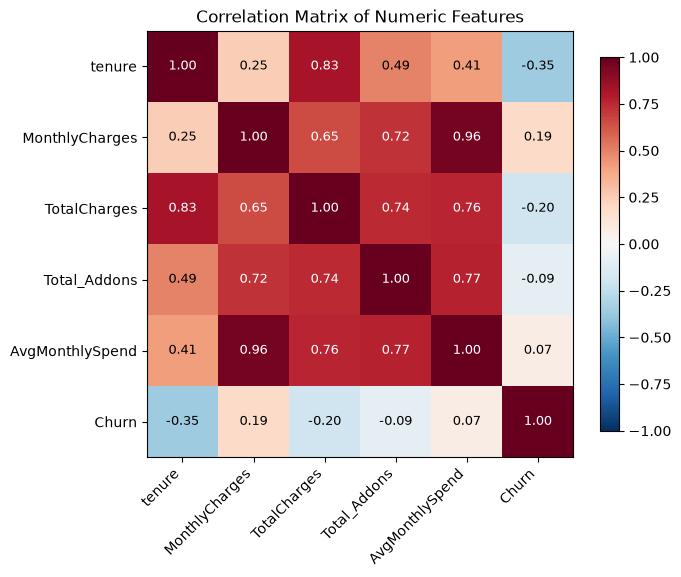

คู่ฟีเจอร์ที่ซ้ำซ้อนกันมากที่สุด 4 อันดับแรก
  MonthlyCharges     vs AvgMonthlySpend    =  0.956
  tenure             vs TotalCharges       =  0.826
  Total_Addons       vs AvgMonthlySpend    =  0.771
  TotalCharges       vs AvgMonthlySpend    =  0.765

ข้อสังเกต
  AvgMonthlySpend ที่เราสร้างขึ้นเอง ซ้ำกับ MonthlyCharges ถึง 0.956
  แปลว่าแทบเป็นตัวแปรเดียวกัน การมีทั้งคู่ทำให้โมเดลสับสนว่าจะให้น้ำหนักตัวไหน
  ส่วน tenure กับ TotalCharges ซ้ำกัน 0.826 เพราะยิ่งใช้นาน ยอดสะสมยิ่งเยอะ


In [5]:
# ========== 1. ตรวจสอบความซ้ำซ้อนด้วย Correlation ==========
import matplotlib.pyplot as plt  # นำเข้าไลบรารีสำหรับวาดกราฟ

# คำนวณค่าสหสัมพันธ์ระหว่างตัวแปรตัวเลขทุกคู่ รวมกับเฉลย Churn ด้วย
corr = df_fe[num_features + ['Churn']].corr()

# วาดเป็นตารางสี (Heatmap) ยิ่งสีเข้มยิ่งสัมพันธ์กันมาก
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
# เขียนตัวเลขลงในแต่ละช่อง
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=9)
ax.set_title('Correlation Matrix of Numeric Features')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# หาคู่ที่ซ้ำซ้อนกันมากที่สุด เพื่อดูว่ามีฟีเจอร์ไหนที่บอกข้อมูลเดียวกัน
pairs = []
for i in range(len(num_features)):
    for j in range(i + 1, len(num_features)):
        pairs.append((num_features[i], num_features[j], corr.iloc[i, j]))
pairs.sort(key=lambda t: -abs(t[2]))  # เรียงจากค่าสัมบูรณ์มากไปน้อย

print("คู่ฟีเจอร์ที่ซ้ำซ้อนกันมากที่สุด 4 อันดับแรก")
for a, b, v in pairs[:4]:
    print(f"  {a:18s} vs {b:18s} = {v: .3f}")

print("\nข้อสังเกต")
print("  AvgMonthlySpend ที่เราสร้างขึ้นเอง ซ้ำกับ MonthlyCharges ถึง 0.956")
print("  แปลว่าแทบเป็นตัวแปรเดียวกัน การมีทั้งคู่ทำให้โมเดลสับสนว่าจะให้น้ำหนักตัวไหน")
print("  ส่วน tenure กับ TotalCharges ซ้ำกัน 0.826 เพราะยิ่งใช้นาน ยอดสะสมยิ่งเยอะ")

แบ่ง Train เดิม 5634 แถว ออกเป็น
  ชุดฝึกย่อย    4507 แถว  ใช้เทรนโมเดลสำหรับวัดความสำคัญ
  ชุด Validation 1127 แถว  ใช้วัดความสำคัญของฟีเจอร์
  ชุด Test       1409 แถว  เก็บไว้ไม่แตะเลย ใช้ตอนวัดผลสุดท้ายเท่านั้น



=== ความสำคัญของฟีเจอร์ (วัดบนชุด Validation, รวม One-hot กลับเป็นตัวแปรเดิม) ===
                  RF Importance  Permutation
Contract                 0.1374       0.0361
InternetService          0.1026       0.0285
tenure                   0.1593       0.0265
TotalCharges             0.1205       0.0072
PaymentMethod            0.0671       0.0047
MonthlyCharges           0.0726       0.0028
PaperlessBilling         0.0140       0.0028
StreamingMovies          0.0210       0.0027
StreamingTV              0.0218       0.0023
OnlineSecurity           0.0452       0.0022
TechSupport              0.0406       0.0017
AvgMonthlySpend          0.0767       0.0013
MultipleLines            0.0108       0.0012
Dependents               0.0114       0.0012
Partner                  0.0091       0.0004
OnlineBackup             0.0308       0.0004
DeviceProtection         0.0197       0.0003
PhoneService             0.0031       0.0000
gender                   0.0070      -0.0001
SeniorCitizen    

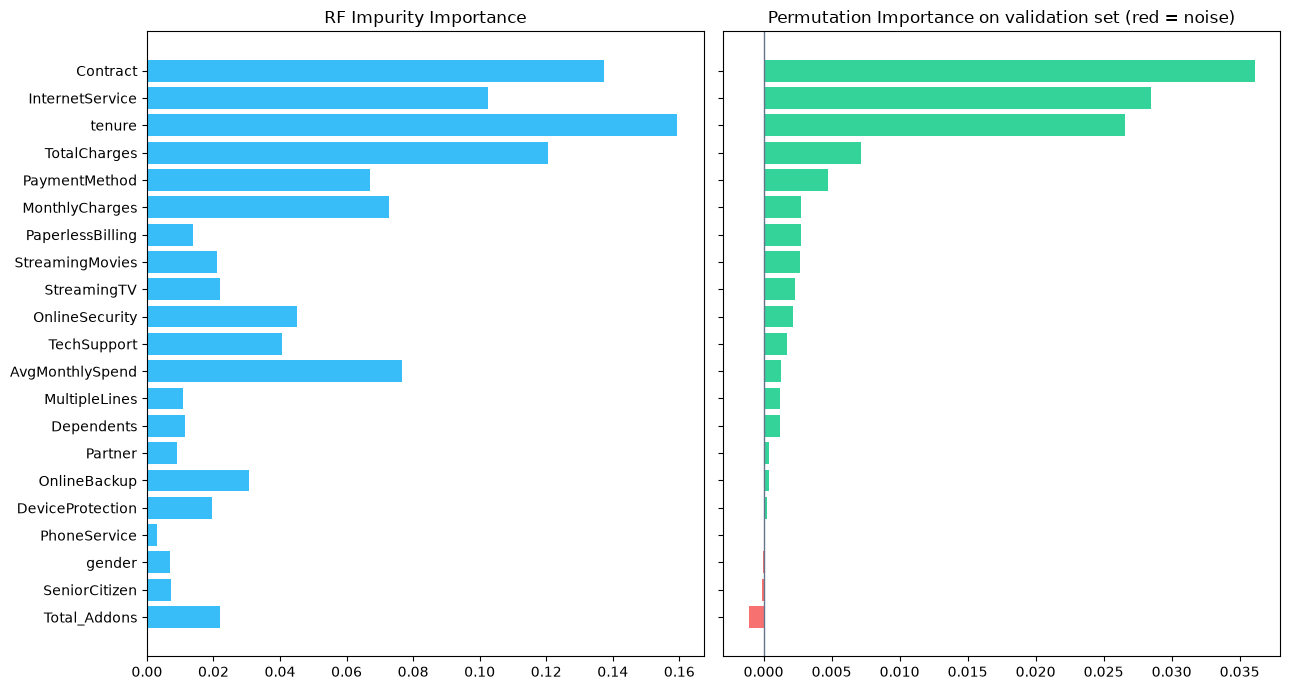


ฟีเจอร์ที่ Permutation ติดลบหรือเป็นศูนย์ = สุ่มสลับค่าทิ้งแล้วโมเดลไม่แย่ลงเลย
  ['gender', 'SeniorCitizen', 'Total_Addons']
  แปลว่าไม่ได้ช่วยทำนายอะไร มีแต่จะทำให้โมเดลซับซ้อนเกินจำเป็น


In [6]:
# ========== 2. วัดความสำคัญของฟีเจอร์ 2 วิธี ==========
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# สำคัญมาก: ห้ามใช้ชุด Test มาคัดเลือกฟีเจอร์
# ถ้าเอา Test มาเลือกฟีเจอร์ แล้ววัดผลด้วย Test ชุดเดิม เท่ากับแอบดูเฉลยก่อนสอบ
# คะแนนที่ได้จะดูดีเกินจริง จึงต้องแบ่งชุด Validation ออกมาจาก Train อีกที
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"แบ่ง Train เดิม {len(X_train)} แถว ออกเป็น")
print(f"  ชุดฝึกย่อย    {len(X_tr2)} แถว  ใช้เทรนโมเดลสำหรับวัดความสำคัญ")
print(f"  ชุด Validation {len(X_val)} แถว  ใช้วัดความสำคัญของฟีเจอร์")
print(f"  ชุด Test       {len(X_test)} แถว  เก็บไว้ไม่แตะเลย ใช้ตอนวัดผลสุดท้ายเท่านั้น")

# เตรียมข้อมูลใหม่โดย fit เฉพาะชุดฝึกย่อยเท่านั้น
pre_fs = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore',
                                               drop='first'))]), cat_features),
])
tr2 = pre_fs.fit_transform(X_tr2)
val = pre_fs.transform(X_val)

# เทรน Random Forest เพื่อใช้วัดความสำคัญโดยเฉพาะ
rf_fs = RandomForestClassifier(n_estimators=200, max_depth=8,
                               class_weight='balanced', random_state=42, n_jobs=-1)
rf_fs.fit(tr2, y_tr2)

# ปัญหา: หลัง One-hot ฟีเจอร์ 1 ตัวถูกแตกเป็นหลายคอลัมน์ เช่น Contract กลายเป็น 2 คอลัมน์
# ถ้าดูคะแนนแยกคอลัมน์จะประเมินต่ำไป จึงต้องรวมคะแนนกลับเป็นตัวแปรเดิมก่อน
onehot_names = pre_fs.get_feature_names_out()

def to_original(name):
    """แปลงชื่อคอลัมน์หลัง One-hot กลับเป็นชื่อตัวแปรเดิม"""
    if name.startswith('num__'):
        return name[5:]
    body = name[5:]  # ตัดคำว่า cat__ ออก
    for c in cat_features:
        if body.startswith(c + '_'):
            return c
    return body

owner = [to_original(n) for n in onehot_names]

# วิธีที่ 1: RF Importance (ดูว่าฟีเจอร์นี้ช่วยแบ่งกิ่งต้นไม้ได้ดีแค่ไหน)
# ข้อเสีย: ลำเอียงเข้าข้างตัวแปรตัวเลขที่มีค่าหลากหลาย
imp_rf = pd.Series(rf_fs.feature_importances_, index=owner).groupby(level=0).sum()

# วิธีที่ 2: Permutation Importance (สุ่มสลับค่าในคอลัมน์นั้นทิ้ง แล้วดูว่าคะแนนตกลงเท่าไร)
# ตกมาก = สำคัญมาก / ไม่ตกเลยหรือดีขึ้น = ไม่สำคัญ เป็นสัญญาณรบกวน
# วัดบนชุด Validation ไม่ใช่ Test
perm = permutation_importance(rf_fs, val, y_val, n_repeats=10,
                              random_state=42, scoring='roc_auc', n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=owner).groupby(level=0).sum()

# รวมสองวิธีเป็นตารางเดียว เรียงตาม Permutation เพราะเชื่อถือได้มากกว่า
rank = pd.DataFrame({'RF Importance': imp_rf, 'Permutation': imp_perm})
rank = rank.sort_values('Permutation', ascending=False)

print("\n=== ความสำคัญของฟีเจอร์ (วัดบนชุด Validation, รวม One-hot กลับเป็นตัวแปรเดิม) ===")
print(rank.round(4).to_string())

# วาดกราฟแท่งเทียบสองวิธี
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
r = rank.iloc[::-1]  # กลับลำดับให้ตัวสำคัญอยู่บน
axes[0].barh(r.index, r['RF Importance'], color='#38bdf8')
axes[0].set_title('RF Impurity Importance')
colors = ['#f87171' if v <= 0 else '#34d399' for v in r['Permutation']]
axes[1].barh(r.index, r['Permutation'], color=colors)
axes[1].set_title('Permutation Importance on validation set (red = noise)')
axes[1].axvline(0, color='#64748b', lw=1)
plt.tight_layout()
plt.show()

noise = rank[rank['Permutation'] <= 0].index.tolist()
print(f"\nฟีเจอร์ที่ Permutation ติดลบหรือเป็นศูนย์ = สุ่มสลับค่าทิ้งแล้วโมเดลไม่แย่ลงเลย")
print(f"  {noise}")
print("  แปลว่าไม่ได้ช่วยทำนายอะไร มีแต่จะทำให้โมเดลซับซ้อนเกินจำเป็น")

=== เปรียบเทียบคะแนนก่อนและหลังการคัดเลือกฟีเจอร์ ===
               จำนวนฟีเจอร์  คอลัมน์หลัง One-hot  LR ROC-AUC  LR PR-AUC  RF ROC-AUC  RF PR-AUC
Top 4                   4.0                  6.0      0.8349     0.6413      0.8365     0.6321
Top 8                   8.0                 13.0      0.8364     0.6238      0.8432     0.6517
Top 12                 12.0                 20.0      0.8437     0.6592      0.8432     0.6567
Top 16                 16.0                 26.0      0.8460     0.6601      0.8430     0.6565
ใช้ทั้งหมด 21          21.0                 32.0      0.8455     0.6587      0.8435     0.6586


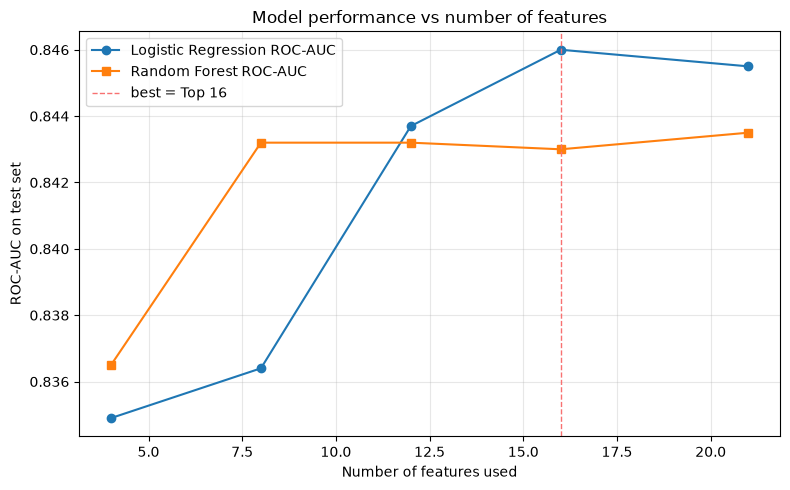

In [7]:
# ========== 3. เปรียบเทียบผลก่อนและหลังการคัดเลือก ==========
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# เรียงฟีเจอร์จากสำคัญมากไปน้อย ตามผล Permutation Importance
ranked = rank.index.tolist()

def evaluate(cols):
    """รับรายชื่อฟีเจอร์ คืนคะแนนของ LR และ RF เมื่อใช้เฉพาะฟีเจอร์ชุดนั้น"""
    n = [c for c in cols if c in num_features]        # แยกกลุ่มตัวเลข
    c_ = [c for c in cols if c not in num_features]   # แยกกลุ่มหมวดหมู่

    parts = []
    if n:
        parts.append(('num', Pipeline([('i', SimpleImputer(strategy='median')),
                                       ('s', StandardScaler())]), n))
    if c_:
        parts.append(('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                                       ('o', OneHotEncoder(handle_unknown='ignore',
                                                           drop='first'))]), c_))
    pre = ColumnTransformer(parts)

    # สำคัญ: fit เฉพาะกับ train แล้ว transform test ห้าม fit ข้อมูล test
    tr = pre.fit_transform(X_train[cols])
    te = pre.transform(X_test[cols])

    out = {'จำนวนฟีเจอร์': len(cols), 'คอลัมน์หลัง One-hot': tr.shape[1]}
    for nm, m in [
        ('LR', LogisticRegression(C=10.0, max_iter=1000,
                                  class_weight='balanced', random_state=42)),
        ('RF', RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=5,
                                      min_samples_leaf=4, class_weight='balanced',
                                      random_state=42, n_jobs=-1)),
    ]:
        m.fit(tr, y_train)
        p = m.predict_proba(te)[:, 1]
        out[f'{nm} ROC-AUC'] = round(roc_auc_score(y_test, p), 4)
        out[f'{nm} PR-AUC'] = round(average_precision_score(y_test, p), 4)
    return out

# ทดลองใช้ฟีเจอร์จำนวนต่างกัน แล้วดูว่าคะแนนเปลี่ยนไปอย่างไร
rows = {}
for k in [4, 8, 12, 16, len(ranked)]:
    label = f'Top {k}' if k < len(ranked) else f'ใช้ทั้งหมด {k}'
    rows[label] = evaluate(ranked[:k])

cmp_df = pd.DataFrame(rows).T
print("=== เปรียบเทียบคะแนนก่อนและหลังการคัดเลือกฟีเจอร์ ===")
print(cmp_df.to_string())

# วาดกราฟเส้นให้เห็นภาพว่าจำนวนฟีเจอร์มีผลต่อคะแนนอย่างไร
ks = [4, 8, 12, 16, len(ranked)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, cmp_df['LR ROC-AUC'], 'o-', label='Logistic Regression ROC-AUC')
ax.plot(ks, cmp_df['RF ROC-AUC'], 's-', label='Random Forest ROC-AUC')
best_k = ks[int(cmp_df['LR ROC-AUC'].values.argmax())]
ax.axvline(best_k, color='#f87171', ls='--', lw=1, label=f'best = Top {best_k}')
ax.set_xlabel('Number of features used')
ax.set_ylabel('ROC-AUC on test set')
ax.set_title('Model performance vs number of features')
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [8]:
# ========== 4. สรุปผลการคัดเลือกฟีเจอร์ ==========
# เลือกชุดที่ให้คะแนน ROC-AUC สูงสุดจากตารางด้านบน
best_k = ks[int(cmp_df['LR ROC-AUC'].values.argmax())]
SELECTED_FEATURES = ranked[:best_k]          # ฟีเจอร์ที่เก็บไว้
DROPPED_FEATURES = ranked[best_k:]           # ฟีเจอร์ที่ตัดทิ้ง

before = cmp_df.loc[f'ใช้ทั้งหมด {len(ranked)}']
after = cmp_df.loc[f'Top {best_k}']

print(f"ฟีเจอร์ที่เลือกใช้ {len(SELECTED_FEATURES)} ตัว")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i:2d}. {f}")

print(f"\nฟีเจอร์ที่ตัดทิ้ง {len(DROPPED_FEATURES)} ตัว")
for f in DROPPED_FEATURES:
    print(f"  - {f}  (Permutation = {rank.loc[f, 'Permutation']:+.4f})")

# ตารางสรุปก่อน-หลัง สำหรับใส่ในรายงาน
summary = pd.DataFrame({
    'ก่อนคัดเลือก': [int(before['จำนวนฟีเจอร์']), int(before['คอลัมน์หลัง One-hot']),
                     before['LR ROC-AUC'], before['LR PR-AUC']],
    'หลังคัดเลือก': [int(after['จำนวนฟีเจอร์']), int(after['คอลัมน์หลัง One-hot']),
                     after['LR ROC-AUC'], after['LR PR-AUC']],
}, index=['จำนวนฟีเจอร์', 'คอลัมน์ที่เข้าโมเดล', 'ROC-AUC', 'PR-AUC'])
summary['ผลต่าง'] = summary['หลังคัดเลือก'] - summary['ก่อนคัดเลือก']

print("\n=== ตารางสรุปก่อน-หลังการคัดเลือก (Logistic Regression) ===")
print(summary.to_string())

# ----- วิเคราะห์ผล (ข้อความอ่านค่าจากผลลัพธ์จริง ไม่ได้เขียนตายตัว) -----
d_roc = after['LR ROC-AUC'] - before['LR ROC-AUC']
d_pr = after['LR PR-AUC'] - before['LR PR-AUC']

print("\n=== วิเคราะห์ผล ===")
print("เกณฑ์ที่ใช้คัดเลือก: Permutation Importance วัดบนชุด Validation ด้วย ROC-AUC")
print("เลือกวิธีนี้เพราะวัดผลกระทบจริงต่อการทำนาย ไม่ลำเอียงเข้าข้างตัวแปรตัวเลข")
print("เหมือน RF Importance แบบปกติ และวัดบน Validation ไม่ใช่ Test")
print("ชุด Test จึงไม่เคยถูกใช้ตัดสินใจอะไรเลย คะแนนสุดท้ายจึงเชื่อถือได้")
print("")

# ตีความขนาดของผลต่างอย่างตรงไปตรงมา
if abs(d_roc) < 0.005:
    print(f"ผลที่ได้: ตัดฟีเจอร์ทิ้ง {len(DROPPED_FEATURES)} ตัว แล้ว ROC-AUC เปลี่ยนไปแค่ {d_roc:+.4f}")
    print(f"และ PR-AUC เปลี่ยนไป {d_pr:+.4f} ซึ่งเล็กเกินกว่าจะสรุปว่าดีขึ้นจริง")
    print("ถือว่าคะแนนเท่าเดิมในทางปฏิบัติ")
    print("")
    print("แต่การคัดเลือกยังคุ้มค่า เพราะได้ประโยชน์ 3 อย่างโดยไม่เสียความแม่นยำเลย")
    print(f"  1. เก็บข้อมูลลูกค้าน้อยลง {len(DROPPED_FEATURES)} ช่อง ตอนใช้งานจริงกรอกฟอร์มสั้นลง")
    print(f"  2. คอลัมน์ที่เข้าโมเดลลดจาก {int(before['คอลัมน์หลัง One-hot'])} เหลือ {int(after['คอลัมน์หลัง One-hot'])} โมเดลเรียบง่ายขึ้น")
    print("  3. อธิบายให้ผู้ใช้เข้าใจง่ายขึ้น ว่าดูจากอะไรบ้าง")
else:
    print(f"ผลที่ได้: ตัดฟีเจอร์ทิ้ง {len(DROPPED_FEATURES)} ตัว แล้ว ROC-AUC เปลี่ยน {d_roc:+.4f}")
    print(f"PR-AUC เปลี่ยน {d_pr:+.4f} ซึ่งเป็นความต่างที่มีนัยสำคัญ")

print("")
top3 = ', '.join(ranked[:3])
print(f"ฟีเจอร์ที่สำคัญที่สุด 3 อันดับแรกคือ {top3}")
print("ตรงกับสามัญสำนึกทางธุรกิจ คือลูกค้าสัญญารายเดือนที่เพิ่งสมัครได้ไม่นาน")
print("และใช้เน็ตไฟเบอร์ซึ่งค่าบริการแพง คือกลุ่มที่พร้อมจะย้ายค่ายมากที่สุด")
print("")

# ตรวจสอบว่าฟีเจอร์ที่เราสร้างขึ้นเองมีประโยชน์จริงหรือไม่
print("ฟีเจอร์ที่สร้างขึ้นเองทั้ง 2 ตัว ผลออกมาต่างกัน")
for f in ['Total_Addons', 'AvgMonthlySpend']:
    keep = 'เก็บไว้' if f in SELECTED_FEATURES else 'ถูกตัดทิ้ง'
    print(f"  {f:16s} อันดับที่ {ranked.index(f) + 1:2d} จาก {len(ranked)}  -> {keep}")
print("บทเรียนคือการสร้างฟีเจอร์ใหม่ไม่ได้ช่วยเสมอไป ต้องวัดผลทุกครั้ง")
print("โดยเฉพาะฟีเจอร์ที่คำนวณจากตัวแปรเดิมที่มีอยู่แล้ว มักซ้ำซ้อนกับของเดิม")

ฟีเจอร์ที่เลือกใช้ 16 ตัว
   1. Contract
   2. InternetService
   3. tenure
   4. TotalCharges
   5. PaymentMethod
   6. MonthlyCharges
   7. PaperlessBilling
   8. StreamingMovies
   9. StreamingTV
  10. OnlineSecurity
  11. TechSupport
  12. AvgMonthlySpend
  13. MultipleLines
  14. Dependents
  15. Partner
  16. OnlineBackup

ฟีเจอร์ที่ตัดทิ้ง 5 ตัว
  - DeviceProtection  (Permutation = +0.0003)
  - PhoneService  (Permutation = +0.0000)
  - gender  (Permutation = -0.0001)
  - SeniorCitizen  (Permutation = -0.0001)
  - Total_Addons  (Permutation = -0.0011)

=== ตารางสรุปก่อน-หลังการคัดเลือก (Logistic Regression) ===
                     ก่อนคัดเลือก  หลังคัดเลือก  ผลต่าง
จำนวนฟีเจอร์              21.0000       16.0000 -5.0000
คอลัมน์ที่เข้าโมเดล       32.0000       26.0000 -6.0000
ROC-AUC                    0.8455        0.8460  0.0005
PR-AUC                     0.6587        0.6601  0.0014

=== วิเคราะห์ผล ===
เกณฑ์ที่ใช้คัดเลือก: Permutation Importance วัดบนชุด Validation ด้วย ROC-A

In [9]:
#Logistic Regression (Linear Baseline — ตีความง่าย)

#Random Forest (Bagging Ensemble)

#Decision Tree (ต้นไม้ตัดสินใจ): ทำงานเหมือนแผนผังคำถาม "ถ้า...แล้ว..." เช่น ถ้าสัญญาเป็นแบบรายเดือน (Month-to-month) และอายุการใช้งานน้อยกว่า 6 เดือน -> เสี่ยงยกเลิกสูง เข้าใจง่ายที่สุด แต่ถ้าต้นไม้โตเกินไปจะจำข้อสอบ (Overfitting)

# คอมเมนต์อธิบายคุณสมบัติโมเดลต่างๆ ของคุณ
from sklearn.linear_model import LogisticRegression # นำเข้าอัลกอริทึม Logistic Regression
from sklearn.tree import DecisionTreeClassifier # นำเข้าอัลกอริทึม Decision Tree (ต้นไม้ตัดสินใจ)
from sklearn.ensemble import RandomForestClassifier # นำเข้าอัลกอริทึม Random Forest (ป่าต้นไม้)
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report # นำเข้าตัวชี้วัดผลงานโมเดล
import pandas as pd # นำเข้า pandas

# สร้างดิกชันนารีเก็บโมเดล 3 ตัวไว้พร้อมตั้งค่าเบื้องต้น
models = {
    # สร้างโมเดล Logistic ตั้งให้น้ำหนักคลาสสมดุลกัน ให้วนลูปหาจุดที่ดีที่สุดสูงสุด 1000 รอบ
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    # สร้างโมเดล Decision Tree จำกัดความลึกของต้นไม้แค่ 5 ชั้นกันการ Overfit ตั้งคลาสให้สมดุล
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    # สร้างโมเดล Random Forest ใช้ต้นไม้ 150 ต้น ความลึกสูงสุด 8 ชั้น ตั้งคลาสให้สมดุล
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42)
}

results = [] # สร้างตัวแปรกล่องเปล่าๆ ไว้เตรียมเก็บคะแนนผลสอบของโมเดล
# วนลูปหยิบเอาชื่อและตัวโมเดลออกมาทีละชุด
for name, model in models.items():
    # 1. เทรนโมเดล (ให้โมเดลเรียนรู้จากข้อมูล X_train, y_train)
    model.fit(X_train_processed, y_train)

    # 2. ให้โมเดลลองทำนายข้อมูลข้อสอบ X_test ให้ออกมาเป็น "ความน่าจะเป็น (เปอเซ็นต์)" และดึงเอาเฉพาะคอลัมน์ 1 (โอกาส Churn)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # 3. คำนวณคะแนนและจดลงในผลลัพธ์
    results.append({
        "Model": name, # บันทึกชื่อโมเดล
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4), # คำนวณคะแนน ROC-AUC ปัดเศษ 4 ตำแหน่ง
        "PR-AUC": round(average_precision_score(y_test, y_prob), 4) # คำนวณคะแนน PR-AUC ปัดเศษ 4 ตำแหน่ง
    })

# แปลงผลลัพธ์เป็นตาราง (DataFrame) และพิมพ์ออกมา
print(pd.DataFrame(results).to_string(index=False))

# ส่วนดึงผลลัพธ์แบบเจาะลึกเฉพาะ Random Forest
rf_model = models["Random Forest"] # หยิบโมเดล Random Forest ที่เทรนเสร็จแล้วออกมาจากดิกชันนารี
y_pred_rf = rf_model.predict(X_test_processed) # สั่งให้ทายผลข้อสอบแบบฟันธง 0 หรือ 1
print("\nClassification Report (Random Forest):") # พิมพ์ชื่อหัวข้อ
# พิมพ์รายงานแบบละเอียด (โชว์ Precision, Recall, F1 Score) ออกมาดู
print(classification_report(y_test, y_pred_rf, target_names=['Stay (0)', 'Churn (1)']))

              Model  ROC-AUC  PR-AUC
Logistic Regression   0.8468  0.6616
      Decision Tree   0.8277  0.5939
      Random Forest   0.8412  0.6545

Classification Report (Random Forest):
              precision    recall  f1-score   support

    Stay (0)       0.91      0.74      0.81      1035
   Churn (1)       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import pandas as pd

# 1. สร้างดิกชันนารีใหญ่ กำหนดตัวโมเดล และ "กรอบการตั้งค่า" (params) ที่อยากให้คอมพิวเตอร์ลองสุ่ม
model_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), # ตัวโมเดลตั้งต้น
        "params": { # สิ่งที่อยากให้ลองสุ่มเปลี่ยน
            "C": [0.01, 0.1, 1.0, 10.0], # ลองเปลี่ยนค่าน้ำหนัก Regularization
            "solver": ['lbfgs', 'liblinear'] # ลองเปลี่ยนอัลกอริทึมในการหาคำตอบ
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight='balanced', random_state=42), # ตัวโมเดลตั้งต้น
        "params": {
            "max_depth": [3, 5, 8, 12], # ลองเปลี่ยนความลึกต้นไม้
            "min_samples_split": [2, 10, 20], # ลองเปลี่ยนจำนวนขั้นต่ำก่อนแตกกิ่ง
            "min_samples_leaf": [1, 5, 10], # ลองเปลี่ยนจำนวนข้อมูลขั้นต่ำที่ใบ
            "criterion": ['gini', 'entropy'] # ลองเปลี่ยนสูตรคำนวณการแตกกิ่ง
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42), # ตัวโมเดลตั้งต้น
        "params": {
            "n_estimators": [100, 200], # ลองเปลี่ยนจำนวนต้นไม้
            "max_depth": [5, 8, 12], # ลองเปลี่ยนความลึก
            "min_samples_split": [5, 10], # ลองเปลี่ยนจำนวนขั้นต่ำก่อนแตกกิ่ง
            "min_samples_leaf": [2, 4] # ลองเปลี่ยนจำนวนข้อมูลขั้นต่ำที่ใบ
        }
    }
}

# 2. เริ่มลูปเพื่อจูนโมเดล
tuned_results = [] # เตรียมตัวแปรลิสต์ไว้เก็บคะแนนสรุป
best_fitted_models = {} # เตรียมตัวแปรดิกชันนารีไว้เก็บตัวโมเดลที่จูนและเก่งที่สุดแล้ว

# วนลูปหยิบชื่อและโครงสร้างโมเดลจาก model_grids ออกมาทีละอัน
for name, config in model_grids.items():
    print(f"--- Tuning {name} ---") # พิมพ์ว่าตอนนี้กำลังเริ่มจูนโมเดลไหนอยู่

    # สร้างระบบ GridSearchCV เพื่อทดลองการตั้งค่าทุกรูปแบบ
    grid = GridSearchCV(
        estimator=config["model"], # ใส่ตัวโมเดลตั้งต้น
        param_grid=config["params"], # ใส่กรอบพารามิเตอร์ที่อยากให้สุ่ม
        scoring='roc_auc', # ให้เลือกการตั้งค่าที่ดีที่สุด โดยดูจากคะแนน roc_auc เป็นหลัก
        cv=5, # แบ่งข้อมูลเทส 5 รอบ (Cross Validation) เพื่อกันโมเดลฟลุ๊คจำข้อสอบ
        n_jobs=-1, # ใช้ทรัพยากร CPU เต็มที่เพื่อให้เทรนเสร็จไวๆ
        verbose=0 # ไม่ต้องพิมพ์สถานะการรันยิบย่อยออกมารกหน้าจอ
    )

    # สั่งให้โมเดลลงมือเทรน (ณ จุดนี้คอมพิวเตอร์จะรันหลายรอบมากตามจำนวน params ที่กำหนด)
    grid.fit(X_train_processed, y_train)

    best_estimator = grid.best_estimator_ # ดึงเอาเวอร์ชันของโมเดลที่พารามิเตอร์ดีที่สุดออกมา
    best_fitted_models[name] = best_estimator # บันทึกโมเดลตัวที่เก่งที่สุดเก็บไว้ในดิกชันนารี

    # นำโมเดลตัวเก่ง ไปลองทำนายคะแนนความน่าจะเป็นกับข้อสอบ (X_test)
    y_prob = best_estimator.predict_proba(X_test_processed)[:, 1]
    roc_test = roc_auc_score(y_test, y_prob) # ตรวจให้คะแนน ROC-AUC
    pr_test = average_precision_score(y_test, y_prob) # ตรวจให้คะแนน PR-AUC

    # จดผลคะแนนและการตั้งค่าที่ได้ลงในลิสต์
    tuned_results.append({
        "Model": name, # ชื่อโมเดล
        "Best Params": grid.best_params_, # พารามิเตอร์ที่ได้คะแนนสูงสุด
        "CV ROC-AUC": round(grid.best_score_, 4), # คะแนนเฉลี่ยตอนทำ Cross Validation ตอนเทรน
        "Test ROC-AUC": round(roc_test, 4), # คะแนน ROC ตอนเทสของจริง
        "Test PR-AUC": round(pr_test, 4) # คะแนน PR ตอนเทสของจริง
    })

# 3. นำคะแนนทั้งหมดมาทำเป็น DataFrame และพิมพ์โชว์
comparison_df = pd.DataFrame(tuned_results)
print("\n=== Tuning Summary Table ===") # พิมพ์หัวข้อตารางคะแนนสรุป
print(comparison_df[['Model', 'CV ROC-AUC', 'Test ROC-AUC', 'Test PR-AUC']].to_string(index=False)) # พิมพ์ตารางคะแนน

print("\n=== Best Parameters Per Model ===") # พิมพ์หัวข้อการตั้งค่าที่ดีที่สุด
# วนลูปพิมพ์บอกทีละโมเดลว่าสรุปแล้ว การตั้งค่าแบบไหนเวิร์คที่สุด
for res in tuned_results:
    print(f"\n[{res['Model']}]")
    print(res['Best Params'])

--- Tuning Logistic Regression ---


--- Tuning Decision Tree ---


--- Tuning Random Forest ---



=== Tuning Summary Table ===
              Model  CV ROC-AUC  Test ROC-AUC  Test PR-AUC
Logistic Regression      0.8482        0.8455       0.6587
      Decision Tree      0.8271        0.8270       0.5978
      Random Forest      0.8453        0.8429       0.6589

=== Best Parameters Per Model ===

[Logistic Regression]
{'C': 10.0, 'solver': 'lbfgs'}

[Decision Tree]
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}

[Random Forest]
{'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


In [11]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

summary_list = [] # เตรียมลิสต์กล่องเปล่าเพื่อเก็บคะแนนใหม่

# วนลูปดึงเอา "โมเดลที่ผ่านการจูนแล้วและเก่งที่สุด" ออกมาจาก best_fitted_models
for name, model in best_fitted_models.items():
    # สั่งให้โมเดลทายผลแบบฟันธง 0 หรือ 1 กับชุดข้อมูลข้อสอบ
    y_pred = model.predict(X_test_processed)
    # สั่งให้โมเดลทายผลแบบบอกเปอเซ็นต์ความน่าจะเป็น ว่ามีโอกาสเป็นคลาส 1 กี่เปอเซ็นต์
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # เพิ่มผลคะแนนลงในลิสต์
    summary_list.append({
        "Model": name, # ชื่อโมเดล
        "Accuracy": f"{accuracy_score(y_test, y_pred) * 100:.2f}%", # หาความแม่นยำ (ทายถูกกี่ %) แปลงฟอร์แมตให้อยู่ในรูป xx.xx%
        "F1 Score (Churn)": round(f1_score(y_test, y_pred, pos_label=1), 4), # คำนวณ F1 Score โดยเน้นให้ความสำคัญที่การทายผลคนที่ Churn (1) เป็นหลัก
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4) # คำนวณ ROC-AUC อีกครั้ง
    })

# เอาลิสต์ผลลัพธ์มาสร้างเป็นตาราง DataFrame
df_metrics = pd.DataFrame(summary_list)
# พิมพ์ตารางผลคะแนนฉบับสุดท้ายออกมา (ซ่อนเลข index ไว้เพื่อความสวยงาม)
print("\n=== Metrics Before Tuning (Base Models) ===")
base_summary_list = [] # สร้างลิสต์ใหม่เพื่อเก็บคะแนนก่อนจูน

for name, model in models.items():
    # ให้โมเดลตั้งต้นทำนายข้อสอบ (แบบฟันธง 0/1)
    y_pred_base = model.predict(X_test_processed)
    # ให้โมเดลตั้งต้นทำนายข้อสอบ (แบบความน่าจะเป็น เพื่อหา ROC-AUC)
    y_prob_base = model.predict_proba(X_test_processed)[:, 1]

    # คำนวณ Accuracy, F1 Score และ ROC-AUC
    base_summary_list.append({
        "Model": name,
        "Accuracy": f"{accuracy_score(y_test, y_pred_base) * 100:.2f}%",
        "F1 Score (Churn)": round(f1_score(y_test, y_pred_base, pos_label=1), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob_base), 4)
    })

# สร้างและปริ้นท์ตารางก่อนจูน
df_base_metrics = pd.DataFrame(base_summary_list)
print(df_base_metrics.to_string(index=False))

# ปริ้นท์ตารางหลังจูน (อันเดิมที่คุณมีอยู่แล้ว)
print("\n=== Metrics After Tuning (Base Models) ===")
print(df_metrics.to_string(index=False))




=== Metrics Before Tuning (Base Models) ===
              Model Accuracy  F1 Score (Churn)  ROC-AUC
Logistic Regression   74.17%            0.6176   0.8468
      Decision Tree   72.39%            0.6090   0.8277
      Random Forest   75.30%            0.6314   0.8412

=== Metrics After Tuning (Base Models) ===
              Model Accuracy  F1 Score (Churn)  ROC-AUC
Logistic Regression   73.95%            0.6149   0.8455
      Decision Tree   70.76%            0.5937   0.8270
      Random Forest   75.51%            0.6357   0.8429
